# One-room place fields with `indiv_traj` training

Same workflow as `demo.ipynb`, but trains on **one cycles room** using the
`indiv_traj` mode: one trajectory at a time, split into 8 segments (batch size 8)
instead of all 128×4 trajectories in parallel (batch 512).

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch

from cycles.cycles_data import load_manifest, load_room
from cycles.cycles_paths import ROOMS_DIR
from cycles.cycles_train import (
    CyclesConfig,
    _train_room_visit,
    rebatch_trajectories,
    trajectory_rebatch_params,
)
from cycles.constants import STEP_SIZE
from cell_evolutions.cell_evolution_model import build_rae, compute_ratemap, masking
from utils import visualize_response_map

## Load one cycles room

In [2]:
ROOM_ID = 1

manifest = load_manifest()
arena_map, raw_traj_coord, wsm, room_spec = load_room(ROOM_ID, manifest=manifest)

print(f"Room: {room_spec.name} ({ROOMS_DIR / room_spec.rel_dir})")
print(f"Arena map: {arena_map.shape}")
print(f"Trajectories: {raw_traj_coord.shape}")
print(f"WSM cells: {wsm.n_cells}")

Room: room_01 (/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/trajectories/cycles/room_01)
Arena map: (110, 110)
Trajectories: (128, 12000, 2)
WSM cells: 200


## WSM response map

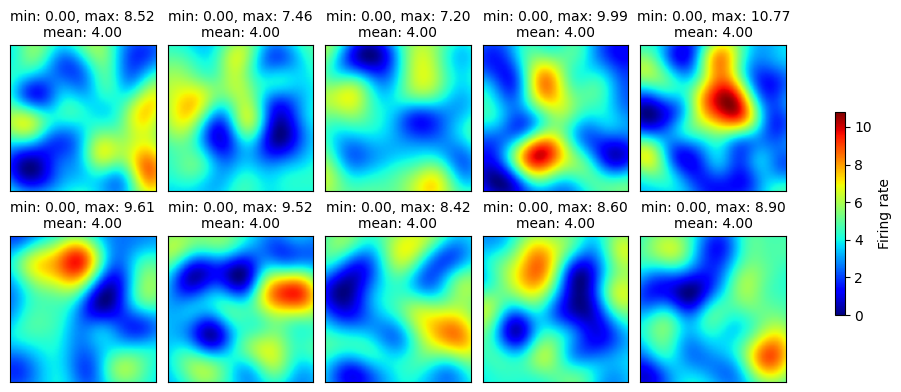

In [3]:
visualize_response_map(wsm.response_map, im_width=2)

## Initialize the RAE

In [4]:
DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

config = CyclesConfig(train_mode="indiv_traj")
rae = build_rae(config.n_wsm_cells, config.n_hidden, DEVICE)
optimizer = torch.optim.Adam(rae.parameters(), lr=config.learning_rate)
mask_generator = torch.Generator(device="cpu")
mask_generator.manual_seed(config.mask_rng_seed)

print(f"Device: {DEVICE}")
print(f"Config: {config}")

Device: cuda
Config: CyclesConfig(n_wsm_cells=200, n_hidden=1000, learning_rate=0.0005, lambda_mse=1.0, lambda_fr=200.0, mask_rate=0.5, step_size=20, n_cycles=30, n_rooms=20, schedule_seed=0, mask_rng_seed=0, record_n_segments=None, train_mode='indiv_traj', device=None)


## Masking sanity check

In [5]:
res = wsm.get_response(raw_traj_coord[:, :1000])
res = masking(
    torch.as_tensor(res, dtype=torch.float32, device=DEVICE),
    config.mask_rate,
    generator=mask_generator,
)
print(f"Mask rate: {config.mask_rate:.0%}")
print(f"Fraction of zeros after masking: {torch.sum(res == 0) / res.numel():.2%}")

Mask rate: 50%
Fraction of zeros after masking: 50.18%


## Initial RAE place fields (untrained)

Rate maps use the full `(128, T, 2)` trajectories, same as `demo.ipynb` before rebatching.

Rate map:   0%|          | 0/500 [00:00<?, ?it/s]

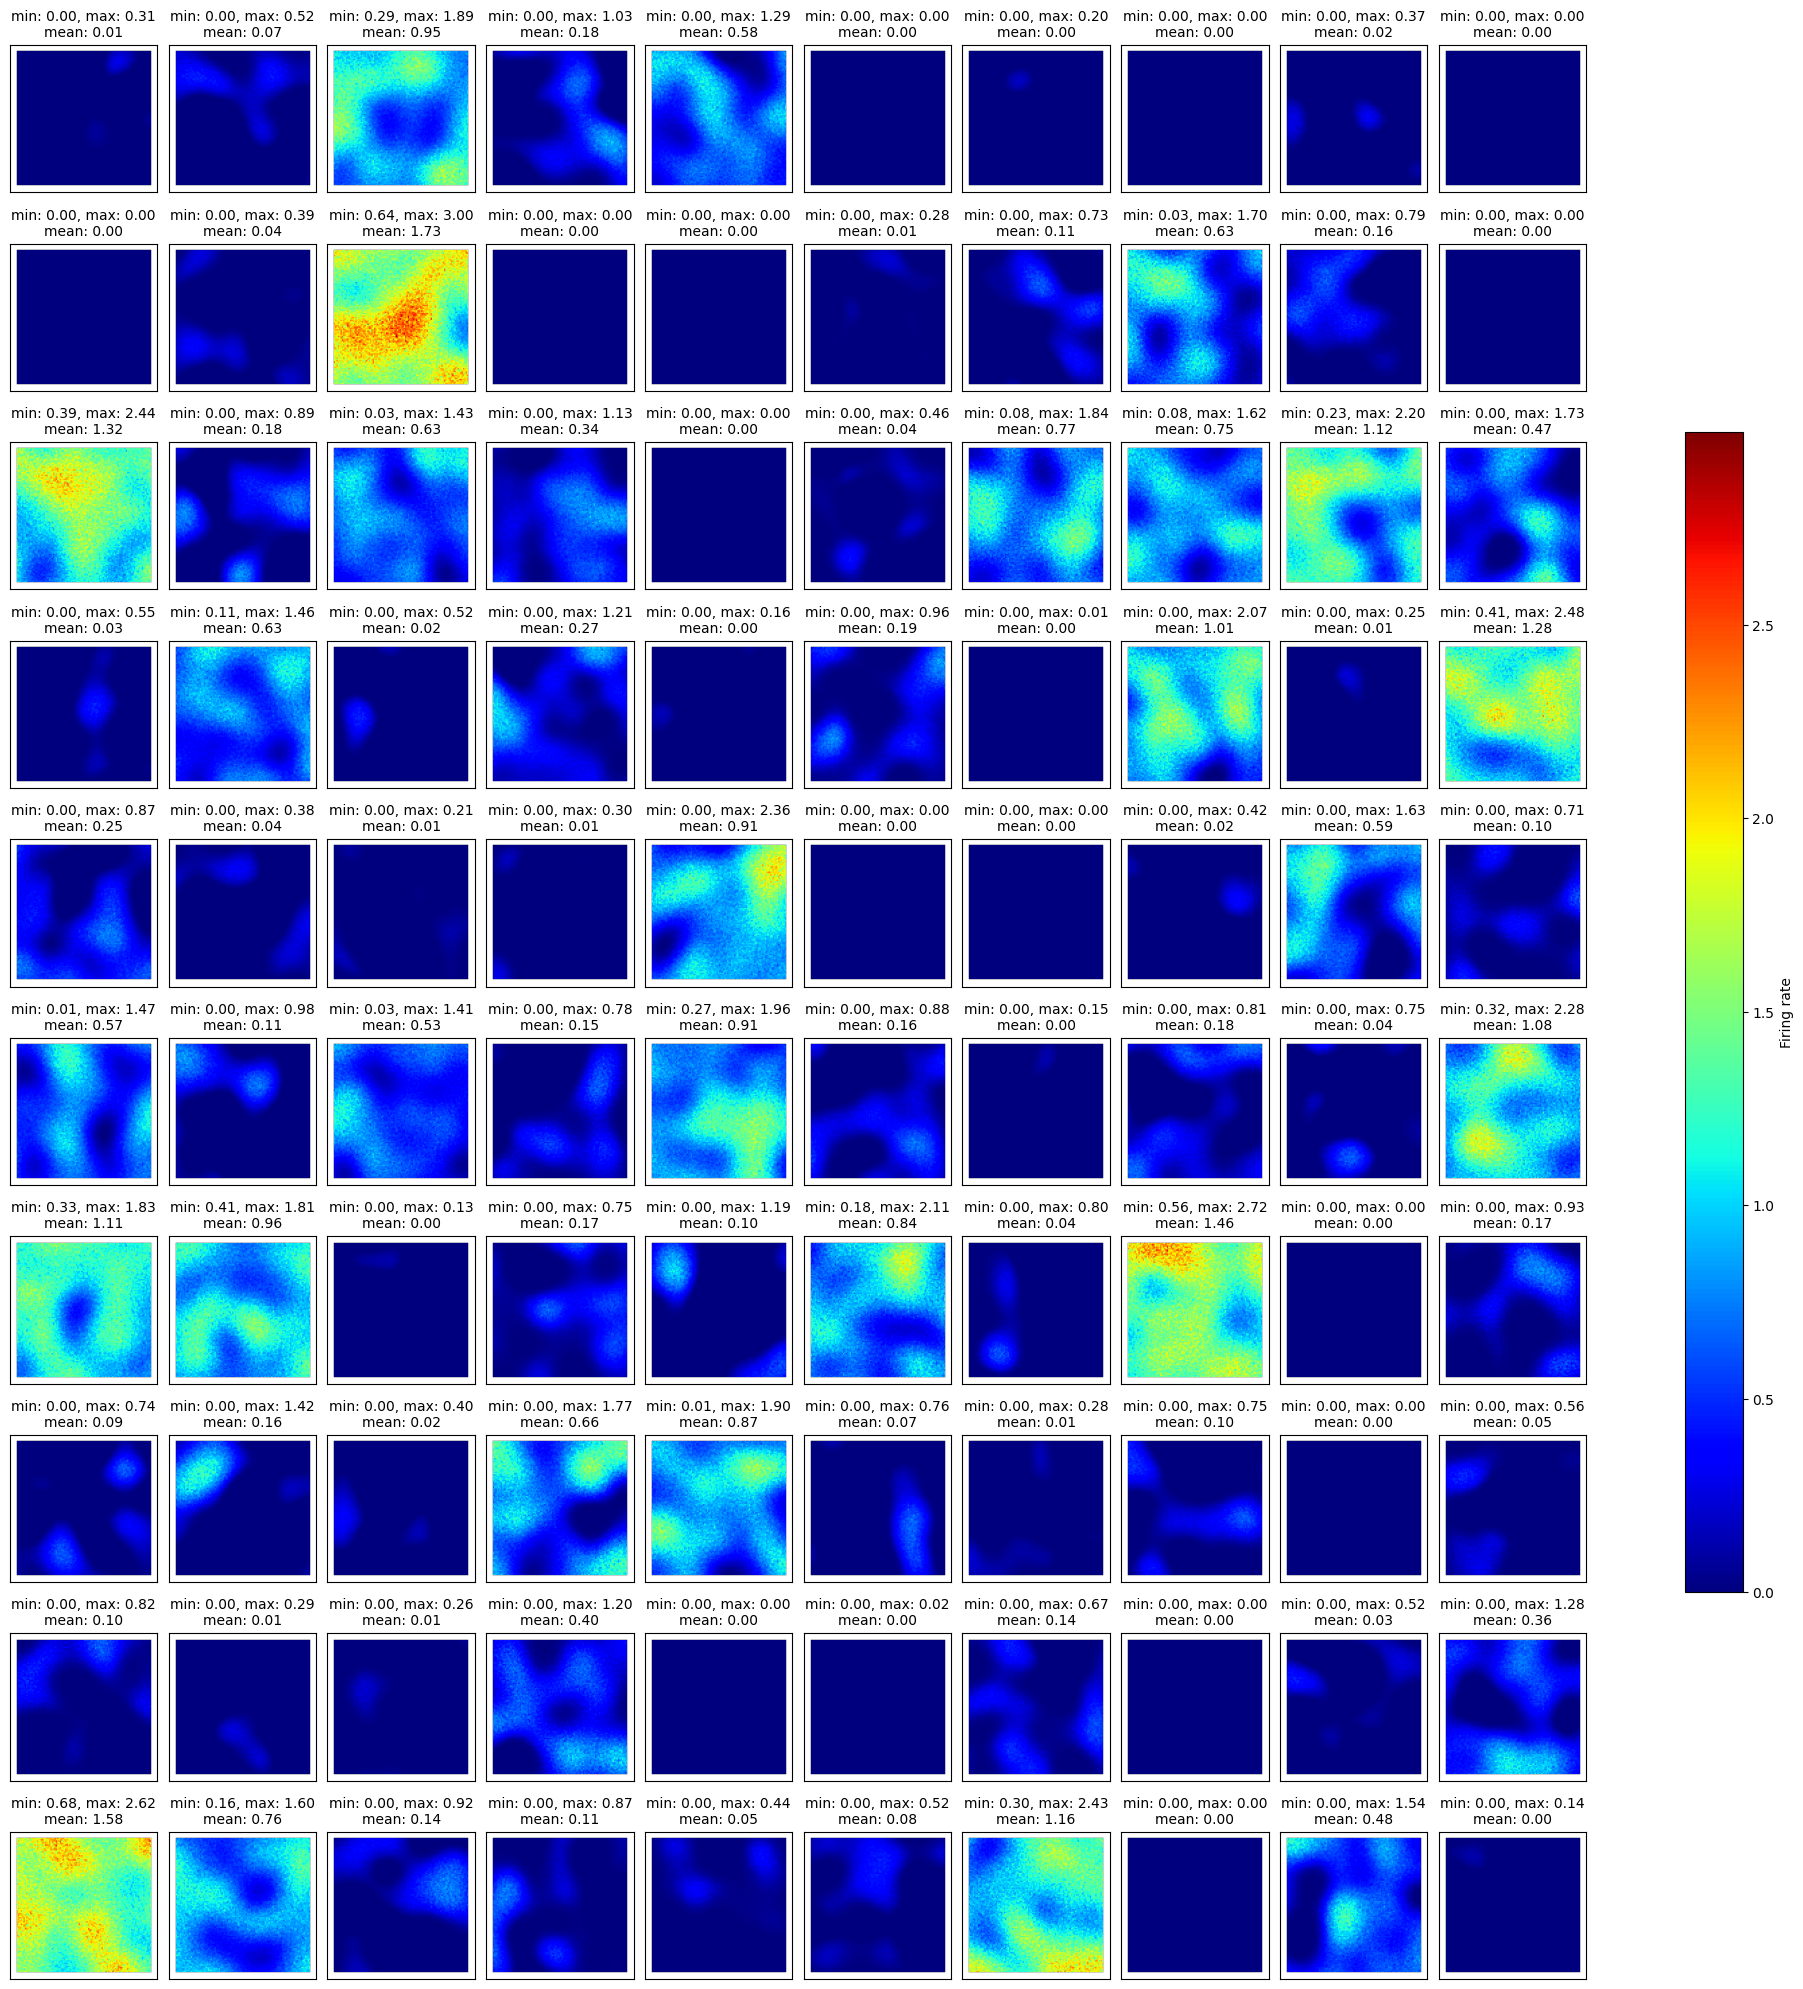

In [6]:
n_test = min(500, raw_traj_coord.shape[1] // STEP_SIZE)
rm_init = compute_ratemap(
    rae,
    raw_traj_coord,
    wsm,
    arena_map,
    DEVICE,
    config.mask_rate,
    config.step_size,
    n_test=n_test,
    mask_generator=mask_generator,
    show_progress=True,
)

N_COLS = 10
N_ROWS = min(10, rm_init.shape[0] // N_COLS)
visualize_response_map(
    rm_init,
    random_cell=False,
    im_width=2,
    n_cols=N_COLS,
    n_rows=N_ROWS,
)

## Train one room visit (`indiv_traj`)

For each of the 128 trajectories, split into 8 temporal segments and train with
batch size 8. Hidden state resets across segments (independent batch items).

In [7]:
print(
    f"Training {raw_traj_coord.shape[0]} trajectories, "
    f"8 segments each, {raw_traj_coord.shape[1] // 8 // STEP_SIZE} steps per segment"
)

_train_room_visit(
    rae,
    optimizer,
    raw_traj_coord,
    wsm,
    DEVICE,
    config,
    mask_generator,
)

print("Done.")

Training 128 trajectories, 8 segments each, 75 steps per segment
Done.


## Final RAE place fields (after `indiv_traj` training)

Rate maps rebatch all trajectories with 8 segments `(1024, T//8, 2)` so segment
boundaries reset hidden state, but all trajectories run in parallel (no gradients).

Rate-map batch shape: (1024, 1500, 2)


Rate map:   0%|          | 0/75 [00:00<?, ?it/s]

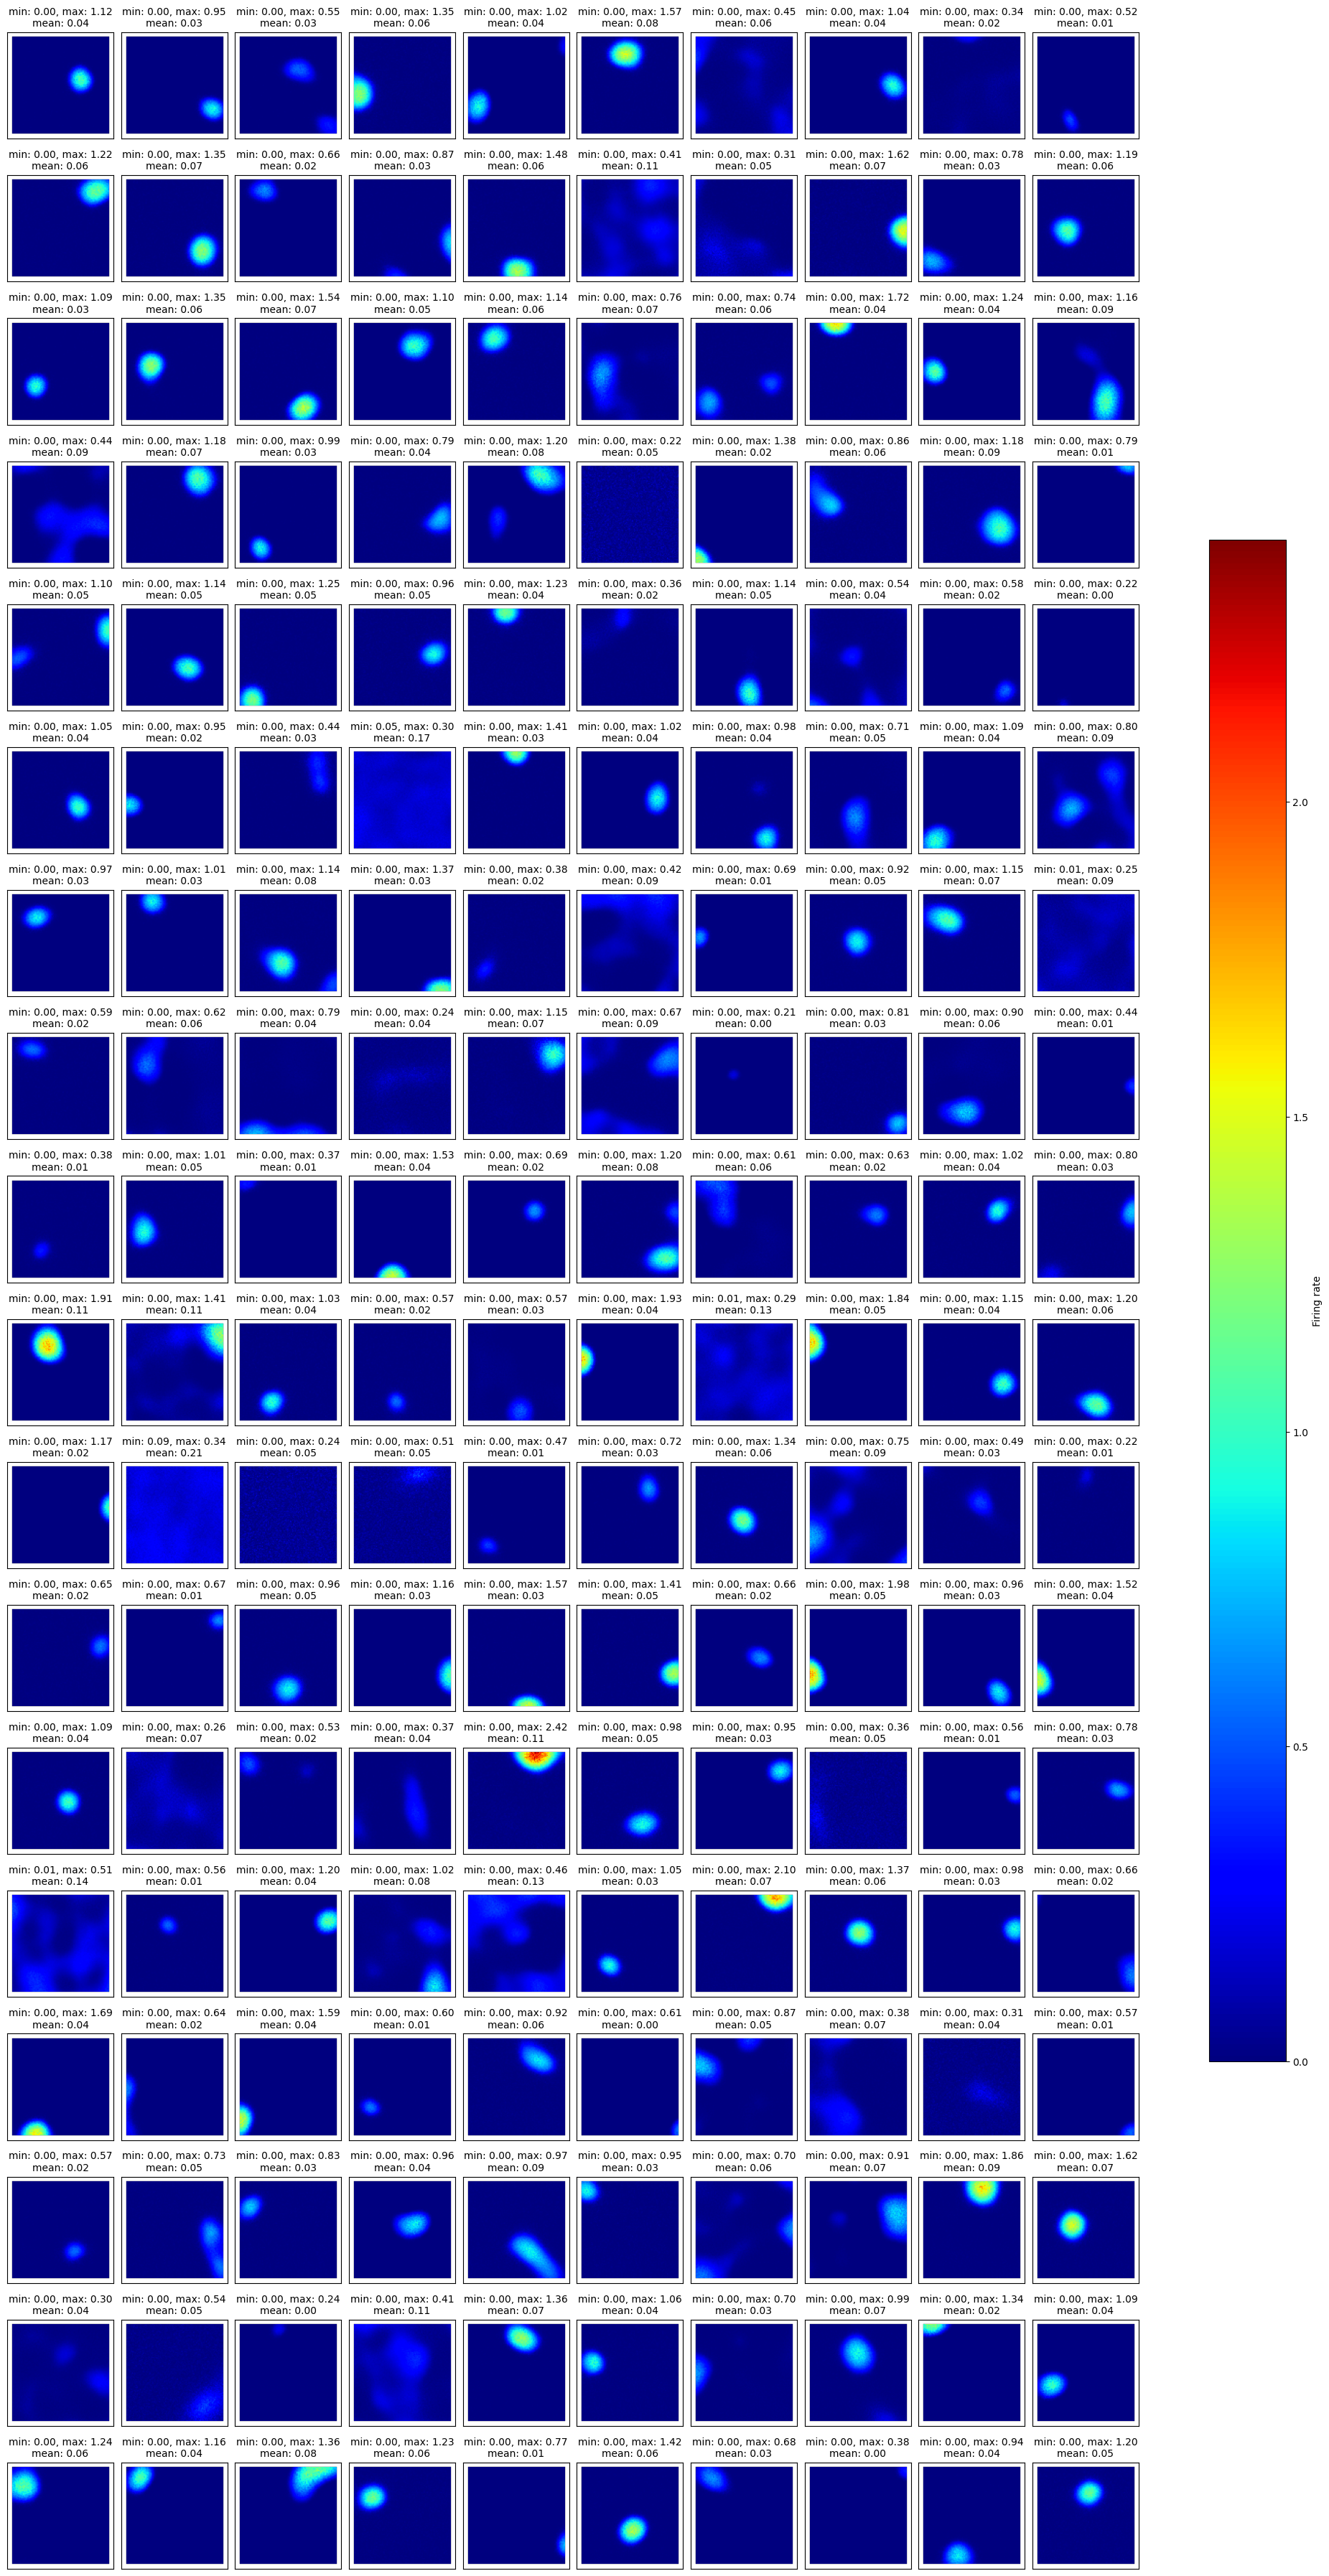

In [8]:
n_seg = trajectory_rebatch_params(config.train_mode)
traj_for_ratemap = rebatch_trajectories(raw_traj_coord, n_segments=n_seg)
print(f"Rate-map batch shape: {traj_for_ratemap.shape}")

record_segments = config.record_n_segments or traj_for_ratemap.shape[1] // STEP_SIZE
rm = compute_ratemap(
    rae,
    traj_for_ratemap,
    wsm,
    arena_map,
    DEVICE,
    config.mask_rate,
    config.step_size,
    n_test=record_segments,
    mask_generator=mask_generator,
    show_progress=True,
)

rm = rm[np.nanmax(rm, axis=(1, 2)) > 0.2]
N_COLS = 10
N_ROWS = min(100, rm.shape[0] // N_COLS)
visualize_response_map(
    rm,
    random_cell=False,
    im_width=2,
    n_cols=N_COLS,
    n_rows=N_ROWS,
)